In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
df = pd.read_csv("datasets/nilai-gizi.csv")
df.head()

,,name,manufacturer,serving_size,energy_kcal,protein_g,carbohydrate_g,fat_g,sugar_g,sodium_mg,fiber_g,...,carbohydrate_percentage_dv,fat_percentage_dv,sodium_percentage_dv,Lemak jenuh,Natrium,Protein,Karbohidrat total,Energi,Lemak total,Serat pangan
Ikan sunu,asin,mentah,Tidak Diketahui,20.30 g,199.0,34.1,7.1,3.8,0.0,377.00,0.00,...,2.18,5.67,25.13,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Soto pekalongan,masakan,Tidak Diketahui,1.30 g,94.0,3.0,5.1,6.8,0.0,0.0,0.30,4.37,...,10.15,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,NaN
Marie duo,Tidak Diketahui,1 g,15.0,1.0,14.0,3.5,5.0,85.0,1.0,4.19,1.67,...,5.67,10.00,6.00,0.0,0.0,0.0,0.0,0.0,NaN,NaN
Kaparende,sayur,Tidak Diketahui,1.30 g,38.0,2.4,2.6,2.0,0.0,170.0,1.50,1.77,...,2.99,11.33,0.00,0.0,0.0,0.0,0.0,0.0,0.0,NaN
Kacang lebui / iris,Tidak Diketahui,3.60 g,346.0,16.5,66.6,1.5,0.0,17.0,37.3,16.09,27.50,...,1.13,0.00,0.00,0.0,0.0,0.0,0.0,0.0,NaN,NaN


In [3]:
df.shape

(1651, 22)

In [4]:
df.drop_duplicates(inplace=True)

In [5]:
#Data Cleaning dan Pre-processing EDA = utk mengetahui penyakit data
df.isnull().sum()

name                             1
manufacturer                     1
serving_size                     1
energy_kcal                      1
protein_g                        1
carbohydrate_g                   1
fat_g                            1
sugar_g                          1
sodium_mg                        1
fiber_g                          1
energy_percentage_dv             1
protein_percentage_dv            1
carbohydrate_percentage_dv       1
fat_percentage_dv                1
sodium_percentage_dv             1
Lemak jenuh                      1
Natrium                          1
Protein                          1
Karbohidrat total                1
Energi                           1
Lemak total                   1143
Serat pangan                  1531
dtype: int64

In [6]:
df['name'] #data baru yg telah diproses

Ikan sunu                         asin                            mentah
Soto pekalongan                   masakan                Tidak Diketahui
Marie duo                        Tidak Diketahui                     1 g
Kaparende                         sayur                  Tidak Diketahui
Kacang lebui / iris              Tidak Diketahui                  3.60 g
                                                              ...       
V-soy Soya bean Milk Low Sugar   PT. Sukanda djaya                2.70 g
Prenagen Esensis                 PT.Sanghiang perkasa                6 g
Pisang ketip                      segar                  Tidak Diketahui
Sapi                              daging                         dendeng
Kacang tanah rebus dengan kulit  Tidak Diketahui                  2.30 g
Name: name, Length: 1596, dtype: object

In [7]:
# Persentil
print(df.describe())

       carbohydrate_g         fat_g      sugar_g    sodium_mg      fiber_g  \
count     1595.000000   1595.000000  1595.000000  1595.000000  1595.000000   
mean         5.933868    100.763135    24.216815    12.611129    11.447172   
std         13.933067    413.452593   108.590467    52.067158    33.081381   
min          0.000000      0.000000     0.000000     0.000000     0.000000   
25%          0.000000      0.000000     0.000000     2.330000     1.750000   
50%          0.500000      0.000000     0.900000     5.860000     5.000000   
75%          6.000000     34.000000     4.000000    13.020000    13.330000   
max        201.000000  11998.000000  1724.000000  1068.000000  1081.000000   

       energy_percentage_dv  protein_percentage_dv  \
count           1595.000000            1595.000000   
mean              10.321755              11.921925   
std               11.229915              18.476601   
min                0.000000               0.000000   
25%                3.380000

<Axes: >

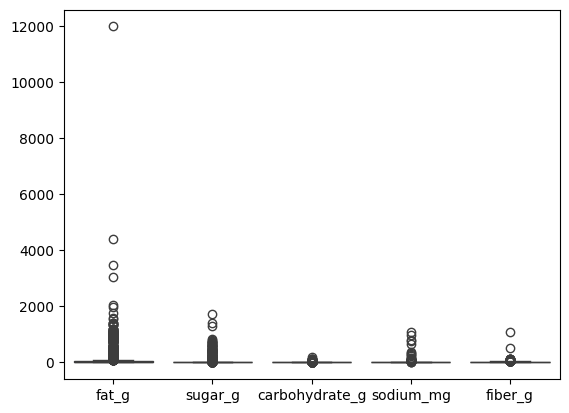

In [8]:
# deteksi outliers dgn seaborn
cols = ['fat_g', 'sugar_g', 'energy_kcal', 'protein_g', 'carbohydrate_g', 'sodium_mg', 'fiber_g']

df_plot = df.reset_index()
sns.boxplot(data=df_plot[cols])

In [9]:
# === STEP PENTING: KONVERSI KE ANGKA ===
# Daftar kolom gizi yang wajib jadi angka
cols_to_fix = ['sugar_g', 'sodium_mg', 'fat_g', 'energy_kcal', 'protein_g', 'fiber_g']

for col in cols_to_fix:
    # 1. Paksa ubah jadi angka (errors='coerce' akan mengubah teks error jadi NaN/Kosong)
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # 2. Isi data kosong (NaN) dengan 0 agar bisa dihitung
    df[col] = df[col].fillna(0)

print("konversi tipe data")
print(df[cols_to_fix].dtypes)

konversi tipe data
sugar_g        float64
sodium_mg      float64
fat_g          float64
energy_kcal    float64
protein_g      float64
fiber_g        float64
dtype: object


In [10]:
# 1. KONFIGURASI AMBANG BATAS PER SAJIAN
# Batas merah (jika melebihi maka buruk)
LIMIT_GULA_GRAM = 5.0
LIMIT_GARAM_MG = 300.0
LIMIT_LEMAK_GRAM = 5.0
LIMIT_KALORI = 200.0

# Batas bonus sehat (lebih dari ini dianggap poin baik/pengurang)
BONUS_PROTEIN_GRAM = 8.0
BONUS_SERAT_GRAM = 3.0

# === 2. FUNGSI LOGIKA PELABELAN ===
def klasifikasi_nutrisi(row):
    """
    Fungsi ini menerima satu baris data (row) dan mengembalikan Label.
    Logika: Sistem Poin (Semakin tinggi skor, semakin tidak sehat).
    """
    skor = 0
    
    # A. PEMBERIAN POIN NEGATIF
    if row['sugar_g'] > LIMIT_GULA_GRAM:
        skor += 1
    
    if row['sodium_mg'] > LIMIT_GARAM_MG:
        skor += 1
        
    if row['fat_g'] > LIMIT_LEMAK_GRAM:
        skor += 1
        
    if row['energy_kcal'] > LIMIT_KALORI:
        skor += 1
    
    # B. PEMBERIAN POIN POSITIF (BONUS POINTS) 
    # Protein & Serat bisa menetralkan nilai buruk
    if row['protein_g'] > BONUS_PROTEIN_GRAM:
        skor -= 1
        
    if row['fiber_g'] > BONUS_SERAT_GRAM:
        skor -= 1
        
    # C. PENENTUAN LABEL AKHIR
    if skor < 0:
        return 'Sehat'
    elif skor == 0:
        return 'Kurang Sehat'
    else:
        return 'Tidak Sehat'

# === 3. EKSEKUSI KE DATASET ===
# pastikan df adalah dataframe yang sudah bersih tadi
df['Label_Kelas'] = df.apply(klasifikasi_nutrisi, axis=1)

# === 4. CEK HASIL ===
print("Contoh 5 Data Teratas dengan Label Baru:")
print(df[['name', 'energy_kcal', 'sugar_g', 'Label_Kelas']].head())

print("\nJumlah Makanan per Kategori:")
print(df['Label_Kelas'].value_counts())

Contoh 5 Data Teratas dengan Label Baru:
                                                name  energy_kcal  sugar_g  \
Ikan sunu            asin                     mentah        199.0      0.0   
Soto pekalongan      masakan         Tidak Diketahui          3.0      0.0   
Marie duo           Tidak Diketahui              1 g         14.0      1.0   
Kaparende            sayur           Tidak Diketahui          2.4    170.0   
Kacang lebui / iris Tidak Diketahui           3.60 g         66.6     37.3   

                                      Label_Kelas  
Ikan sunu            asin            Kurang Sehat  
Soto pekalongan      masakan                Sehat  
Marie duo           Tidak Diketahui   Tidak Sehat  
Kaparende            sayur            Tidak Sehat  
Kacang lebui / iris Tidak Diketahui   Tidak Sehat  

Jumlah Makanan per Kategori:
Label_Kelas
Sehat           786
Kurang Sehat    550
Tidak Sehat     260
Name: count, dtype: int64


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# cek keseimbangan data
print('Jumlah data per kategori')
print(df['Label_Kelas'].value_counts())

# seleksi fitur (membuat x dan y)
# X = data gizi
fitur_gizi = ['sugar_g', 'sodium_mg', 'fat_g', 'energy_kcal', 'protein_g', 'fiber_g']
X = df[fitur_gizi] 

# y = label kelas (jawaban)
y = df['Label_Kelas']

# encoding label "sehat" -> 0, "kurang sehat" -> 1, "tidak sehat" -> 2
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("\nContoh Label yang sudah diubah ke angka:", y_encoded[:5])
print("Mapping Label:", dict(zip(le.classes_, le.transform(le.classes_))))

# Split data Train dan Testing
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Scaling supaya distribusi data jadi normal
scaler = StandardScaler()

# Model belajar scaling dari data train aja (X_train) lalu terapkan ke X_test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Data Latihan: {X_train.shape[0]} baris")
print(f"Data Ujian: {X_test.shape[0]} baris")

Jumlah data per kategori
Label_Kelas
Sehat           786
Kurang Sehat    550
Tidak Sehat     260
Name: count, dtype: int64

Contoh Label yang sudah diubah ke angka: [0 1 2 2 2]
Mapping Label: {'Kurang Sehat': np.int64(0), 'Sehat': np.int64(1), 'Tidak Sehat': np.int64(2)}
Data Latihan: 1276 baris
Data Ujian: 320 baris


mulai cross-val menggunakan data X_train_scaled aja (data latihan)
Random Forest: Rata-rata Akurasi = 0.9803 (Std Dev: 0.0151)
XGBoost: Rata-rata Akurasi = 0.9788 (Std Dev: 0.0140)
KNN: Rata-rata Akurasi = 0.8029 (Std Dev: 0.0373)


/tmp/ipykernel_42078/3569660510.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results, labels=names, showmeans=True)


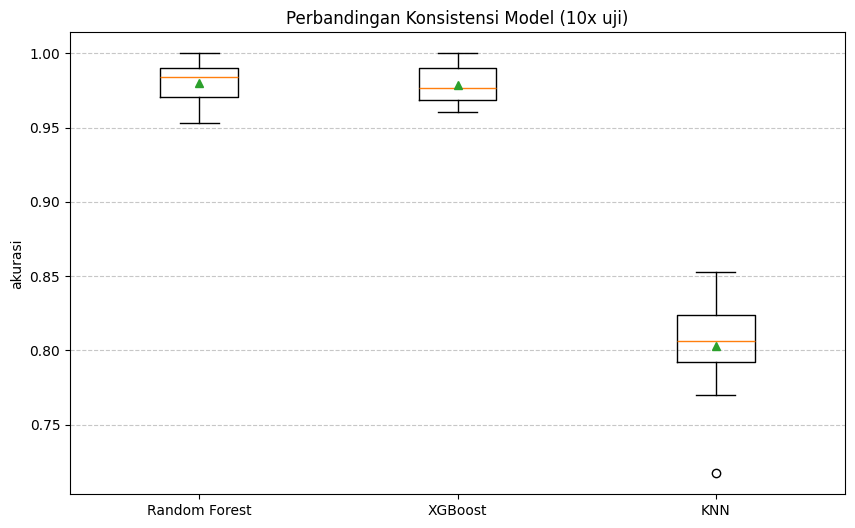


model tertinggi: Random Forest


In [12]:
# Cross-Val [TEMPAT LATIHAN]
from unittest import result
from matplotlib.lines import lineStyles
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

models = [
    ('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')),
    ('XGBoost', XGBClassifier(eval_metric='mlogloss',random_state=42)),
    ('KNN', KNeighborsClassifier(n_neighbors=5))
]

#skenario uji 10x putaran
#StratifiedKFold memastikan "Tidak Sehat" tersebar rata di setiap testing
KFold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

results = []
names = []
scoring = 'f1_weighted' # akurasi

print('mulai cross-val menggunakan data X_train_scaled aja (data latihan)')

for name, model in models:
    cv_results = cross_val_score(model, X_train_scaled, y_train, cv=KFold, scoring=scoring)
    
    results.append(cv_results)
    names.append(name)
    
    print(f"{name}: Rata-rata Akurasi = {cv_results.mean():.4f} (Std Dev: {cv_results.std():.4f})")

# visualisasi perbandingan
plt.figure(figsize=(10,6))
plt.boxplot(results, labels=names, showmeans=True)
plt.title('Perbandingan Konsistensi Model (10x uji)')
plt.ylabel('akurasi')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

# menentukan mdoel dgn rata2 skor tertinggi
best_index = -1
best_score = 0

for i in range(len(results)):
    if results[i].mean() > best_score:
        best_score = results[i].mean()
        best_index = i

print(f"\nmodel tertinggi: {names[best_index]}")